<div style="background-color: #d1ecf1; color: #0c5460; padding: 10px; border-radius: 5px; font-weight: bold; font-size: 18px;"><b><h3><align = "center">
  TASK 03 : Data Preprocessing
</div></h3></b>




**Module:** CCS3440 – Artificial Intelligence  
**Prediction Task:** Appointment No-Show Prediction (Option A)



## 1. Import Libraries

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


## 2. Load the Dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
DATA_DIR = "/content/drive/MyDrive/AI_Coursework/Dataset"
file_path = os.path.join(DATA_DIR, "smartcare_ai_dataset_1000.csv")

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


## 3. Initial Data Quality Check

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))


Rows: 1000
Columns: 33

Data types:


,Data Type
record_id,int64
patient_id,object
age,int64
gender,object
blood_group,object
department,object
diagnosis,object
appointment_date,object
waiting_days,int64
previous_appointments,int64



Missing values:


,Missing Values
record_id,0
patient_id,0
age,0
gender,0
blood_group,0
department,0
diagnosis,0
appointment_date,0
waiting_days,0
previous_appointments,0


## 4. Missing Value Handling

The dataset contains missing values in `room_type`. Because room type is not applicable to patients who were not admitted, those records are assigned **Not Applicable**. For admitted patients, missing room types are replaced using the mode among admitted patients.

Any remaining categorical missing values are filled using the mode. Numerical missing values, if present, are handled using the median, which is less sensitive to extreme observations than the mean.


In [ ]:
missing_before = df.isnull().sum()
print("Missing values before treatment:")
display(missing_before[missing_before > 0].to_frame("Missing Values"))


Missing values before treatment:


,Missing Values
room_type,906


In [ ]:
# Numerical missing values: median imputation
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Room type: domain-specific treatment
if "room_type" in df.columns:
    df.loc[df["admitted"] == 0, "room_type"] = (
        df.loc[df["admitted"] == 0, "room_type"]
        .fillna("Not Applicable")
    )

    admitted_mode = df.loc[df["admitted"] == 1, "room_type"].mode()
    if not admitted_mode.empty:
        df.loc[df["admitted"] == 1, "room_type"] = (
            df.loc[df["admitted"] == 1, "room_type"]
            .fillna(admitted_mode.iloc[0])
        )

# Remaining categorical missing values: mode
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

print("Missing values after treatment:", int(df.isnull().sum().sum()))
display(df.isnull().sum()[df.isnull().sum() > 0].to_frame("Remaining Missing Values"))


Missing values after treatment: 0


,Remaining Missing Values


## 5. Duplicate Record Detection

In [ ]:
duplicate_count = int(df.duplicated().sum())
print("Duplicate records detected:", duplicate_count)


Duplicate records detected: 0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", df.shape)
print("Duplicate records remaining:", int(df.duplicated().sum()))


Dataset shape after duplicate removal: (1000, 33)
Duplicate records remaining: 0


## 6. Outlier Identification and Treatment

Outliers are identified using the **Interquartile Range (IQR)** method.

For each numerical predictor:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Extreme values are **capped** at these boundaries rather than deleting patient records. This reduces the influence of extreme observations while preserving the dataset size.


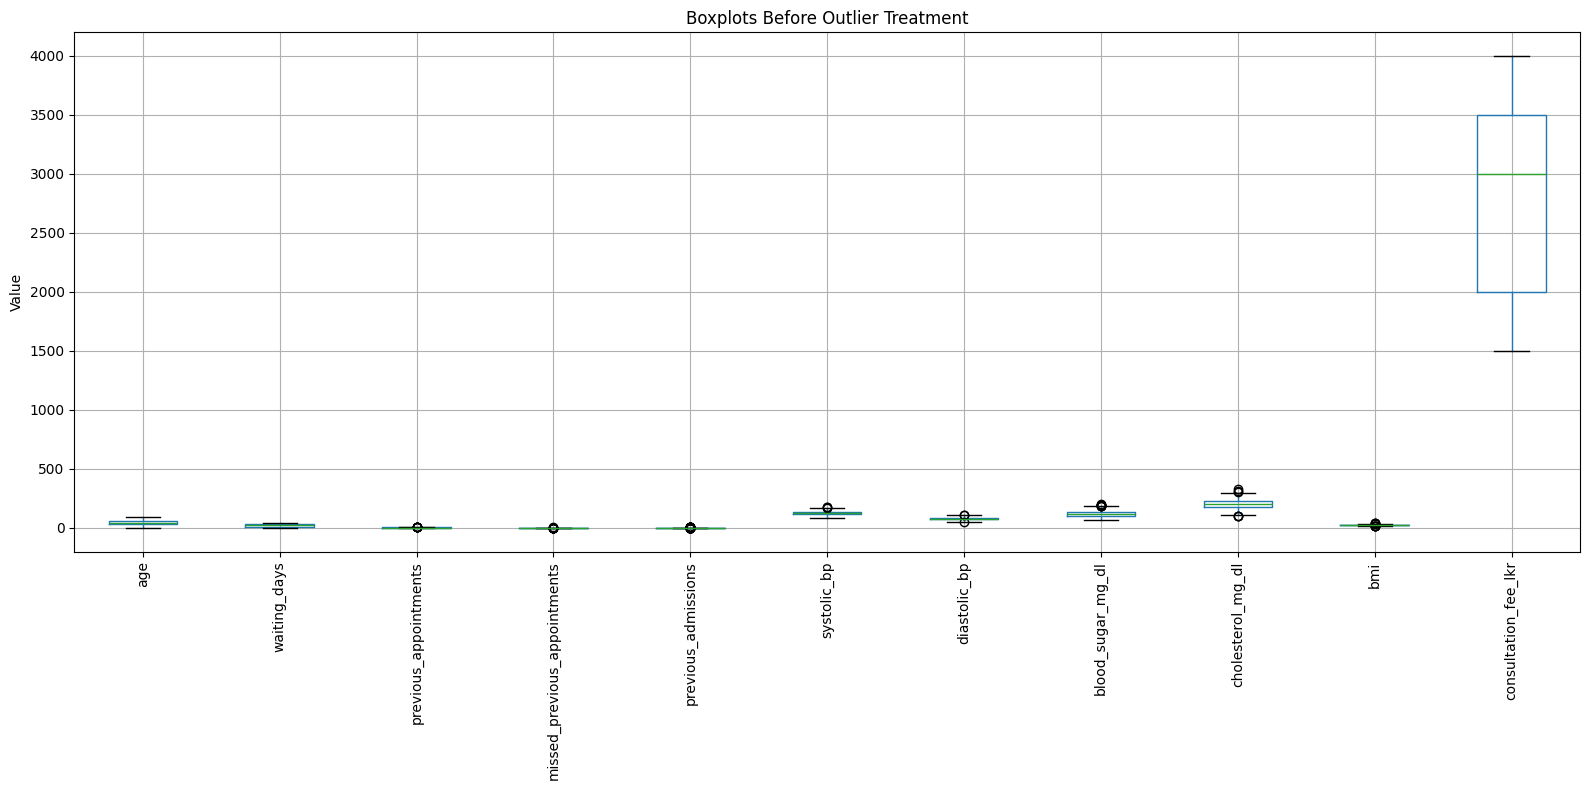

In [ ]:
# Exclude identifiers and target variables from outlier treatment
outlier_exclusions = [
    "record_id",
    "patient_id",
    "no_show",
    "readmitted_30_days",
    "disease_risk_level",

    # Post-appointment / post-visit features
    "admitted",
    "room_type",
    "length_of_stay_days",
    "lab_tests_count",
    "treatments_count",
    "room_charge_lkr",
    "lab_charge_lkr",
    "medicine_charge_lkr",
    "total_bill_lkr",
]

outlier_columns = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in outlier_exclusions
]

plt.figure(figsize=(16, 8))
df[outlier_columns].boxplot(rot=90)
plt.title("Boxplots Before Outlier Treatment")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


In [ ]:
outlier_summary = []

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = int(mask.sum())

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outlier_count
    })

    # Winsorisation / capping
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,age,33.0,57.0,24.0,-3.0,93.0,0
1,waiting_days,11.0,34.0,23.0,-23.5,68.5,0
2,previous_appointments,2.0,4.0,2.0,-1.0,7.0,8
3,missed_previous_appointments,0.0,1.0,1.0,-1.5,2.5,17
4,previous_admissions,0.0,1.0,1.0,-1.5,2.5,60
5,systolic_bp,117.0,139.0,22.0,84.0,172.0,3
6,diastolic_bp,72.0,86.0,14.0,51.0,107.0,3
7,blood_sugar_mg_dl,97.0,132.0,35.0,44.5,184.5,10
8,cholesterol_mg_dl,180.0,230.0,50.0,105.0,305.0,6
9,bmi,22.7,28.3,5.6,14.3,36.7,9


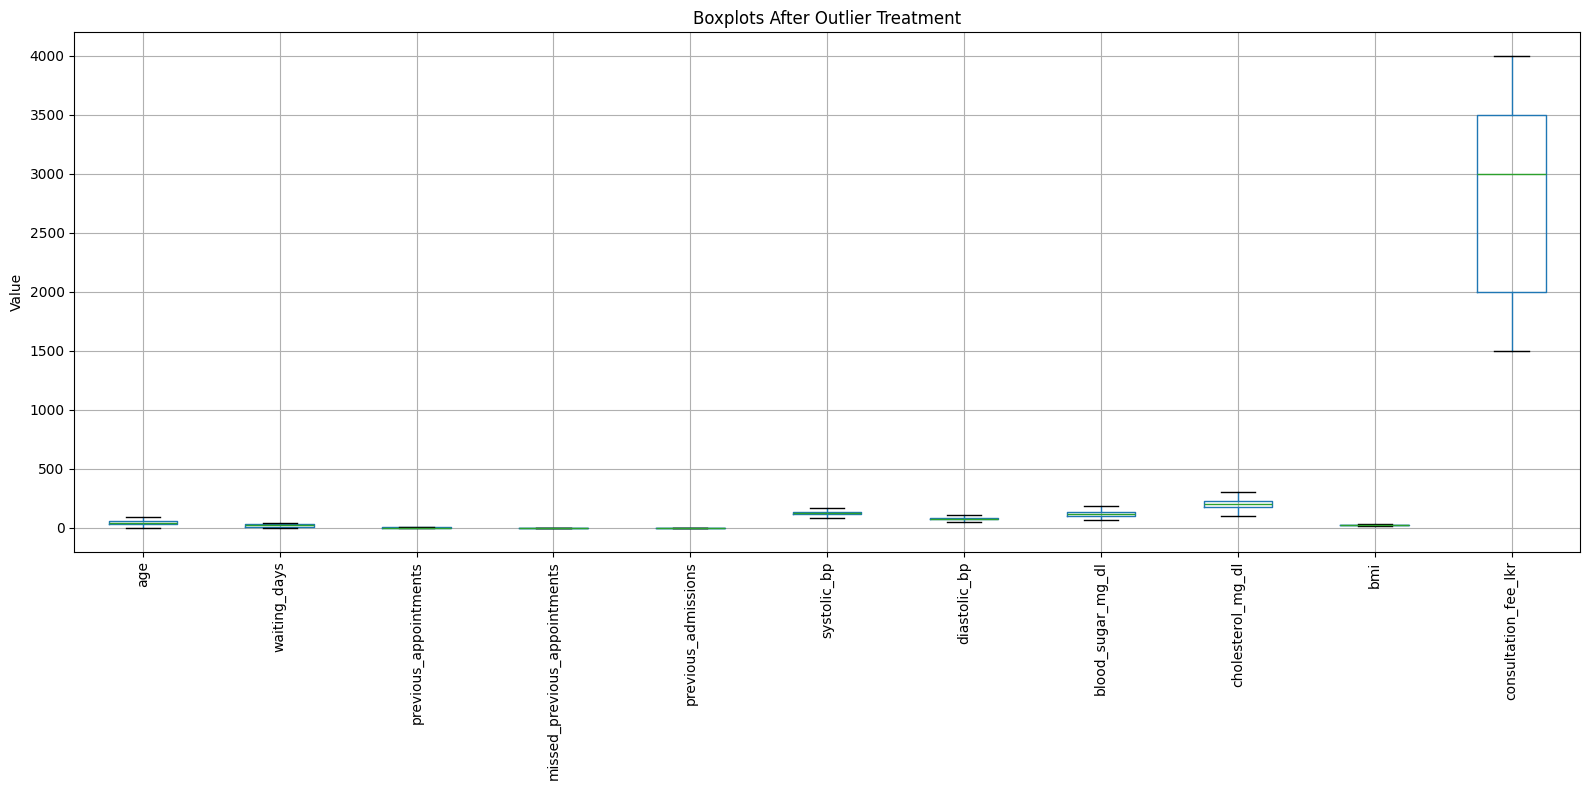

In [ ]:
plt.figure(figsize=(16, 8))
df[outlier_columns].boxplot(rot=90)
plt.title("Boxplots After Outlier Treatment")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


## 7. Feature Engineering

### 7.1 Age Group

Age is converted into meaningful age categories. This can help the model capture non-linear patterns between age groups and appointment attendance.


In [ ]:
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[0, 18, 35, 50, 65, 100],
    labels=["Child", "Young Adult", "Adult", "Middle Age", "Senior"]
)

display(df["Age_Group"].value_counts(dropna=False).to_frame("Count"))


,Count
Age_Group,
Adult,318
Middle Age,253
Young Adult,239
Senior,120
Child,70


### 7.2 High Blood Pressure

A binary feature is created to indicate whether systolic or diastolic blood pressure reaches commonly used high-BP thresholds.


In [ ]:
df["High_BP"] = (
    (df["systolic_bp"] >= 140) |
    (df["diastolic_bp"] >= 90)
).astype(int)

display(df["High_BP"].value_counts().to_frame("Count"))


,Count
High_BP,
0,646
1,354


### 7.3 Previous Appointment Miss Rate

This feature represents the patient's historical tendency to miss appointments. `+1` in the denominator prevents division by zero for patients with no previous appointments.


In [ ]:
df["Missed_Rate"] = (
    df["missed_previous_appointments"] /
    (df["previous_appointments"] + 1)
)

display(df["Missed_Rate"].describe().to_frame("Missed_Rate"))


,Missed_Rate
count,1000.000000
mean,0.142253
std,0.204406
min,0.000000
25%,0.000000
50%,0.000000
75%,0.250000
max,1.000000


## 8. Feature Selection




In [ ]:
target = "no_show"

columns_to_remove = [
    "record_id",
    "patient_id",
    "appointment_status",
    "appointment_date",
    "readmitted_30_days",
    "disease_risk_level",
    "admitted",
    "room_type",
    "length_of_stay_days",
    "lab_tests_count",
    "treatments_count",
    "room_charge_lkr",
    "lab_charge_lkr",
    "medicine_charge_lkr",
    "total_bill_lkr",
    "payment_status",
    "payment_method",

    target
]

X = df.drop(columns=columns_to_remove)
y = df[target].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nSelected features:")
print(X.columns.tolist())

X = df.drop(columns=columns_to_remove)
y = df[target].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nSelected features:")
print(X.columns.tolist())


Feature matrix shape: (1000, 18)
Target shape: (1000,)

Selected features:
['age', 'gender', 'blood_group', 'department', 'diagnosis', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'consultation_fee_lkr', 'Age_Group', 'High_BP', 'Missed_Rate']
Feature matrix shape: (1000, 18)
Target shape: (1000,)

Selected features:
['age', 'gender', 'blood_group', 'department', 'diagnosis', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'consultation_fee_lkr', 'Age_Group', 'High_BP', 'Missed_Rate']


## 9. Categorical Feature Encoding

In [ ]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)


Categorical features:
['gender', 'blood_group', 'department', 'diagnosis', 'Age_Group']


In [ ]:
# Encode categorical variables.

label_encoders = {}

for col in categorical_features:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col].astype(str))
    label_encoders[col] = encoder

print("Encoding completed.")
display(X.head())


Encoding completed.


,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,consultation_fee_lkr,Age_Group,High_BP,Missed_Rate
0,53,1,1,1,8,10,1,0.0,1.0,127,75,117.0,211,26.1,2000,2,0,0.000
1,26,1,5,1,3,2,3,1.0,0.0,130,73,136.0,173,32.8,2000,4,0,0.250
2,22,1,4,4,1,22,7,1.0,1.0,141,64,90.0,176,29.4,2500,4,1,0.125
3,44,0,3,0,0,16,1,0.0,0.0,124,82,126.0,189,24.9,2000,0,0,0.000
4,51,0,6,3,6,12,4,0.0,1.0,119,81,65.0,195,27.0,4000,2,0,0.000


## 10. Feature Scaling

Feature scaling is required because numerical variables have very different ranges. For example, `age` is measured in years while financial variables are measured in LKR.

**Data leakage prevention:** the dataset is split into training and testing sets **before** fitting `StandardScaler`. The scaler learns mean and standard deviation from `X_train` only, then transforms both `X_train` and `X_test`.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).rename("Proportion").to_frame())

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).rename("Proportion").to_frame())


Training set: (800, 18)
Testing set: (200, 18)

Training target distribution:


,Proportion
no_show,
0,0.505
1,0.495



Testing target distribution:


,Proportion
no_show,
0,0.505
1,0.495


In [ ]:
scaler = StandardScaler()

# Scale all model input features after the train/test split.
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling completed.")
display(X_train_scaled.head())


Scaling completed.


,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,consultation_fee_lkr,Age_Group,High_BP,Missed_Rate
769,0.230917,-1.002503,-1.046184,-1.446307,-1.612328,-0.314725,1.842172,2.057089,-0.980023,0.484399,-0.266704,-0.078021,0.675366,-0.669572,-0.969519,-1.216233,-0.733799,0.708189
483,-0.379131,0.997503,-1.480061,1.030246,-1.268273,0.381869,0.068010,-0.766886,0.226159,-0.421171,-0.960731,0.572749,1.835950,-0.716624,-0.376087,-1.216233,-0.733799,-0.693941
730,-0.157296,0.997503,-1.046184,1.030246,-0.924218,1.078462,-1.114765,-0.766886,-0.980023,-0.938640,-0.365851,-0.307704,0.216530,0.906653,-0.376087,-1.216233,-0.733799,-0.693941
437,-0.157296,-1.002503,-0.178432,0.534935,0.452002,-1.707912,-1.114765,-0.766886,1.432342,1.001868,0.625615,0.457907,-0.026383,0.483190,-1.562950,-1.216233,1.362770,-0.693941
984,-0.379131,-1.002503,0.689321,1.030246,0.107947,0.072272,0.659397,2.057089,-0.980023,1.584021,2.013667,0.419627,0.621385,0.200881,1.404207,-1.216233,1.362770,1.269041


## 11. Final Data Quality Checks

In [ ]:
print("Missing values in X:", int(X.isnull().sum().sum()))
print("Duplicate rows in X:", int(X.duplicated().sum()))
print("Target values:", sorted(y.unique().tolist()))

print("\nFinal feature count:", X.shape[1])
print("Training rows:", len(X_train_scaled))
print("Testing rows:", len(X_test_scaled))


Missing values in X: 0
Duplicate rows in X: 0
Target values: [0, 1]

Final feature count: 18
Training rows: 800
Testing rows: 200


## 12. Save Preprocessed Data

Two outputs are saved:

1. **`clean_dataset.csv`** – cleaned, feature-engineered and encoded data before scaling. This keeps the preprocessing output easy to inspect.
2. **`preprocessed_train_test.joblib`** – leakage-free scaled train/test data, target values, feature names, scaler and encoders for the modelling stage.


In [ ]:
os.makedirs(DATA_DIR, exist_ok=True)

clean_data = pd.concat([X, y], axis=1)

clean_dataset_path = os.path.join(DATA_DIR, "clean_dataset.csv")
clean_data.to_csv(clean_dataset_path, index=False)

preprocessed_path = os.path.join(DATA_DIR, "preprocessed_train_test.joblib")

joblib.dump(
    {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": X.columns.tolist(),
        "scaler": scaler,
        "label_encoders": label_encoders
    },
    preprocessed_path
)

print("Saved:", clean_dataset_path)
print("Saved:", preprocessed_path)


Saved: /content/drive/MyDrive/AI_Coursework/Dataset/clean_dataset.csv
Saved: /content/drive/MyDrive/AI_Coursework/Dataset/preprocessed_train_test.joblib


## 13. Final Summary

In [ ]:
summary = pd.DataFrame({
    "Item": [
        "Original rows",
        "Final rows",
        "Original columns",
        "Final model features",
        "Duplicate records removed",
        "Missing values remaining",
        "Target variable"
    ],
    "Value": [
        1000,
        len(df),
        33,
        X.shape[1],
        duplicate_count,
        int(df.isnull().sum().sum()),
        "no_show"
    ]
})

display(summary)
display(clean_data.head())


,Item,Value
0,Original rows,1000
1,Final rows,1000
2,Original columns,33
3,Final model features,18
4,Duplicate records removed,0
5,Missing values remaining,0
6,Target variable,no_show


,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,consultation_fee_lkr,Age_Group,High_BP,Missed_Rate,no_show
0,53,1,1,1,8,10,1,0.0,1.0,127,75,117.0,211,26.1,2000,2,0,0.000,0
1,26,1,5,1,3,2,3,1.0,0.0,130,73,136.0,173,32.8,2000,4,0,0.250,0
2,22,1,4,4,1,22,7,1.0,1.0,141,64,90.0,176,29.4,2500,4,1,0.125,1
3,44,0,3,0,0,16,1,0.0,0.0,124,82,126.0,189,24.9,2000,0,0,0.000,0
4,51,0,6,3,6,12,4,0.0,1.0,119,81,65.0,195,27.0,4000,2,0,0.000,0
